# Anurag Gupta
## BMC202309
## BSC-3
## NLP Assignment 1

# Import Libraries

In [ ]:
from wiki_dump_reader import Cleaner, iterate
from tqdm import tqdm
from google.colab import files
from google.colab import drive
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from collections import Counter
import math
from tabulate import tabulate
import psutil
import os

## Default paths for Storage

In [ ]:
languages = ["English","Bengali","Hindi"]

lang = [l.lower() for l in languages]

drive.mount('/content/drive/')

dump_files = [f"/content/drive/My Drive/NLP_Files/Wiki_Dump/Dump/{l}_dump.xml" for l in lang]
raw_corpus_files = [f"/content/drive/My Drive/NLP_Files/Wiki_Dump/Corpus/{l}_corpus.txt" for l in lang]
corpus_files = [f"/content/drive/My Drive/NLP_Files/Wiki_Dump/Corpus/{l}_processed.txt" for l in lang]


# Corpus Preparation

In [ ]:

def write_corpus(dump, corpus):
    '''
    Processes Wikipedia XML dump and writes cleaned text to corpus file.
    Extracts titles and text, cleans HTML/formatting, removes links,
    and saves with progress tracking using tqdm.
    '''

    cleaner = Cleaner()

    total_pages = sum(1 for _ in iterate(dump))

    with open(corpus, 'w', encoding='utf-8') as output:

        with tqdm(iterate(dump), total=total_pages, unit="page") as pbar:
            for title, text in pbar:

                text = cleaner.clean_text(text)
                cleaned_text, _ = cleaner.build_links(text)
                output.write(title + '\n' + cleaned_text + '\n') # type: ignore

    print(f"Corpus saved to: {corpus}")

    return total_pages

document_count=[]

for l,dump_file,raw_corpus_file in zip(languages,dump_files,raw_corpus_files):
    print("\nConstructing Corpus for ",l)
    document_count.append(write_corpus(dump_file,raw_corpus_file))



Constructing Corpus for  English
100%|██████████| 345667/345667 [02:29<00:00, 2317.46page/s]
Corpus saved to: /content/drive/My Drive/NLP_Files/Wiki_Dump/Corpus/english_corpus.txt

Constructing Corpus for  Bengali
100%|██████████| 420554/420554 [05:04<00:00, 1382.74page/s] 
Corpus saved to: /content/drive/My Drive/NLP_Files/Wiki_Dump/Corpus/bengali_corpus.txt

Constructing Corpus for  Hindi
100%|██████████| 239021/239021 [04:58<00:00, 799.71page/s] 
Corpus saved to: /content/drive/My Drive/Wiki_Dump/NLP_Files/Corpus/hindi_corpus.txt


In [ ]:

def clean_hindi_line(line):
    '''Cleans Hindi text by removing non-Devanagari characters and normalizing spaces.'''

    cleaned = re.sub(r'[^\u0900-\u097F ]', ' ', line)
    cleaned = re.sub(r'[\u0966-\u096F]', ' ', cleaned)
    cleaned = re.sub(r'[।॥]', ' ', cleaned)
    cleaned = re.sub(r' +', ' ', cleaned)
    cleaned = cleaned.strip()
    return cleaned

def clean_bengali_line(line):
    '''Cleans Bengali text by removing non-Bengali characters and normalizing spaces.'''

    cleaned = re.sub(r'[^\u0980-\u09FF ]', ' ', line)
    cleaned = re.sub(r' +', ' ', cleaned)
    cleaned = cleaned.strip()

    return cleaned

def clean_english_line(line):
    '''Cleans English text by converting to lowercase and removing non-alphabetic characters.'''

    line = line.lower()
    cleaned = re.sub(r'[^a-z ]', ' ', line)
    cleaned = re.sub(r' +', ' ', cleaned)
    cleaned = cleaned.strip()

    return cleaned

language_cleaner = {"Hindi":clean_hindi_line,
                    "Bengali":clean_bengali_line,
                    "English":clean_english_line}

In [ ]:

def preprocess_corpus(clean_line, source_file, dest_file):
    '''
    Preprocesses corpus file by applying language-specific cleaning.
    Reads source file, cleans each line, removes empty lines,
    and writes continuous text to destination file.
    '''

    total_lines=0

    with open(source_file, 'r', encoding='utf-8') as src:
        total_lines=0
        for _ in src:
            total_lines+=1

    try:
        with open(source_file, 'r', encoding='utf-8') as src:
            with open(dest_file, 'w', encoding='utf-8') as dest:

                first_line = True

                with tqdm(src, total=total_lines, unit="line") as pbar:
                    for line in pbar:

                        cleaned_line = clean_line(line)

                        if not cleaned_line:
                            continue

                        if not first_line:
                            dest.write(' ')
                        else:
                            first_line = False

                        dest.write(cleaned_line)

    except Exception as e:
        print(f"An error occurred: {e}")

    print(f"Processed Corpus saved to: {dest_file}")


for l,corpus_file,raw_corpus_file in zip(languages,corpus_files,raw_corpus_files):
    print("\nPre-processing Corpus for ",l)
    preprocess_corpus(language_cleaner[l],raw_corpus_file,corpus_file)



Pre-processing Corpus for  English 
100%|██████████| 7433747/7433747 [00:39<00:00, 186587.96line/s]
Processed Corpus saved to: /content/drive/My Drive/NLP_Files/Wiki_Dump/Corpus/english_processed.txt

Pre-processing Corpus for  Bengali
100%|██████████| 5842328/5842328 [00:45<00:00, 129396.24line/s]
Processed Corpus saved to: /content/drive/My Drive/NLP_Files/Wiki_Dump/Corpus/bengali_processed.txt

Pre-processing Corpus for  Hindi
100%|██████████| 4532808/4532808 [00:39<00:00, 113740.40line/s]
Processed Corpus saved to: /content/drive/My Drive/NLP_Files/Wiki_Dump/Corpus/hindi_processed.txt


In [ ]:
drive.flush_and_unmount()

# finalizing changes into the dirve

In [ ]:
def tokenize_corpus(file_path):
    '''Loads corpus file and splits text into individual words/tokens.'''

    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        words = text.split()
        print(f"Loaded {len(words):,} total words, {len(set(words)):,} unique words")
        return words
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return []
    except Exception as e:
        print(f"Error loading corpus: {e}")
        return []

In [ ]:

def calculate_word_frequencies(words):
    '''
    Calculates word frequency distribution using Counter.
    Returns frequencies, ranks, and word-frequency dictionary
    sorted by frequency in descending order.
    '''

    word_counts = Counter(words)
    sorted_words = word_counts.most_common()
    frequencies = [count for _, count in sorted_words]
    ranks = list(range(1, len(frequencies) + 1))
    return frequencies, ranks, dict(sorted_words)



In [ ]:

def word_analysis(corpus_file):
    '''
    Performs comprehensive word analysis on corpus.
    Tokenizes text, calculates frequencies and ranks,
    and returns tokens with statistical properties.
    '''

    words = tokenize_corpus(corpus_file)

    frequencies, ranks, word_freq_dict = calculate_word_frequencies(words)

    properties={}
    properties['frequencies']=frequencies
    properties['ranks']=ranks
    properties['word_freq_dict']=word_freq_dict

    return words,properties

word_tokens = []
word_properties = []

for i,l,corpus_file in zip([i for i in range(len(languages))],languages,corpus_files):

    print("\nAnalyzing Words for ",l)

    word_stuff = word_analysis(corpus_file)

    word_tokens.append(word_stuff[0])
    word_properties.append(word_stuff[1])


Analyzing Words for  English
Loaded 113,146,814 total words, 1,057,440 unique words

Analyzing Words for  Bengali
Loaded 104,009,930 total words, 1,478,174 unique words

Analyzing Words for  Hindi
Loaded 88,757,626 total words, 868,332 unique words


# Zipf Law and Mandelbrot Law Analysis

In [ ]:


def zipf_law(rank, alpha, C):
    '''Implements Zipf's law formula: frequency = C / (rank^alpha).'''

    return C / (rank ** alpha)

def mandelbrot_law(rank, alpha, beta, C):
    '''Implements Mandelbrot's law formula: frequency = C / ((rank + beta)^alpha).'''

    return C / ((rank + beta) ** alpha)


In [ ]:
def zipf_mandelbrot_models(ranks, frequencies):
    '''
    Fits both Zipf's and Mandelbrot's laws to frequency data.
    Uses curve fitting to estimate parameters and calculates
    R² and RMSE for model evaluation.
    '''

    ranks_np = np.array(ranks)
    freqs_np = np.array(frequencies)
    results = {}

    try:
        def zipf_wrapper(rank, alpha, C):
            return zipf_law(rank, alpha, C)

        initial_guess = [1.0,frequencies[0]]
        params, _ = curve_fit(zipf_wrapper, ranks_np, freqs_np, p0=initial_guess, maxfev=5000)
        alpha_zipf, c_zipf = params

        zipf_pred = zipf_law(ranks_np, alpha_zipf, c_zipf)
        zipf_r2 = r2_score(freqs_np, zipf_pred)
        zipf_rmse = np.sqrt(mean_squared_error(freqs_np, zipf_pred))

        results['zipf'] = {
            'alpha': alpha_zipf,
            'C': c_zipf,
            'r2': zipf_r2,
            'rmse': zipf_rmse,
            'predictions': zipf_pred
        }

    except Exception as e:
        print(f"Error fitting Zipf's law: {e}")
        results['zipf'] = None

    try:
        def mandelbrot_wrapper(rank, alpha, beta, C):
            return mandelbrot_law(rank, alpha, beta, C)

        initial_guess = [1.0, 2.0, frequencies[0]]
        params, _ = curve_fit(mandelbrot_wrapper, ranks_np, freqs_np,
                            p0=initial_guess, maxfev=5000)
        alpha_mandel, beta_mandel , c_mandel= params

        mandel_pred = mandelbrot_law(ranks_np, alpha_mandel, beta_mandel, c_mandel)
        mandel_r2 = r2_score(freqs_np, mandel_pred)
        mandel_rmse = np.sqrt(mean_squared_error(freqs_np, mandel_pred))

        results['mandelbrot'] = {
            'alpha': alpha_mandel,
            'beta': beta_mandel,
            'C': c_mandel,
            'r2': mandel_r2,
            'rmse': mandel_rmse,
            'predictions': mandel_pred
        }
    except Exception as e:
        print(f"Error fitting Mandelbrot's law: {e}")
        results['mandelbrot'] = None

    return results

In [ ]:


def plot_law_analysis(ranks_list, frequencies_list, model_results_list, languages):
    '''
    Creates log-log plots comparing actual frequency data with fitted models.
    Displays Zipf's and Mandelbrot's law fits for multiple languages
    in subplot arrangement.
    '''

    n_languages = len(languages)

    n_cols = n_languages
    n_rows = (n_languages + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

    if n_languages > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    point_colour = 'blue'
    zipf_colour = 'green'
    mandel_colour = 'red'

    for i, (ranks, frequencies, model_results, language) in enumerate(zip(
        ranks_list, frequencies_list, model_results_list, languages)):

        ax = axes[i]
        ranks_np = np.array(ranks)
        freqs_np = np.array(frequencies)

        ax.loglog(ranks_np, freqs_np, 'o', markersize=2, alpha=0.6,
                color=point_colour, label=f'{language} Data')

        if model_results['zipf']:
            zipf_pred = model_results['zipf']['predictions']
            ax.loglog(ranks_np, zipf_pred, '--', linewidth=1.5,
                    color=zipf_colour,
                    label=f'Zipf (α={model_results["zipf"]["alpha"]:.3f})')

        if model_results['mandelbrot']:
            mandel_pred = model_results['mandelbrot']['predictions']
            ax.loglog(ranks_np, mandel_pred, '-', linewidth=1.5,
                    color=mandel_colour,
                    label=f'Mandelbrot (α={model_results["mandelbrot"]["alpha"]:.3f}, β={model_results["mandelbrot"]["beta"]:.3f})')

        ax.set_xlabel('Rank (log scale)')
        ax.set_ylabel('Frequency (log scale)')
        ax.set_title(f'{language} - Rank-Frequency Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


In [ ]:

def identify_deviation_points(ranks, frequencies, model_results):
    '''
    Identifies points of maximum deviation between actual data and models.
    Calculates relative errors and returns rank positions where
    Zipf's and Mandelbrot's laws deviate most from observed frequencies.
    '''

    ranks_np = np.array(ranks)
    freqs_np = np.array(frequencies)
    deviations = {}

    if model_results['zipf']:
        zipf_rel_error = np.abs((freqs_np - model_results['zipf']['predictions']) / freqs_np)
        max_zipf_dev = np.argmax(zipf_rel_error)
        deviations['zipf'] = {
            'max_deviation_rank': ranks_np[max_zipf_dev],
            'max_deviation_error': zipf_rel_error[max_zipf_dev]
        }

    if model_results['mandelbrot']:
        mandel_rel_error = np.abs((freqs_np - model_results['mandelbrot']['predictions']) / freqs_np)
        max_mandel_dev = np.argmax(mandel_rel_error)
        deviations['mandelbrot'] = {
            'max_deviation_rank': ranks_np[max_mandel_dev],
            'max_deviation_error': mandel_rel_error[max_mandel_dev]
        }

    return deviations


In [ ]:

def print_zipf_prediction(model_results_list, languages):
    '''
    Prints formatted comparison table of Zipf and Mandelbrot model parameters.
    Displays alpha, beta, R², and RMSE values with quality assessment
    for each language.
    '''

    print('\n')
    print("=" * 80)
    print("MODEL PARAMETERS AND FIT QUALITY - COMPARISON")
    print("=" * 80)

    table_data = []
    headers = ["Language", "Model", "Alpha (α)", "Beta (β)", "R²", "RMSE"]

    for language, model_results in zip(languages, model_results_list):

        if model_results['zipf']:
            table_data.append([
                language,
                "Zipf's Law",
                f"{model_results['zipf']['alpha']:.6f}",
                "N/A",
                f"{model_results['zipf']['r2']:.6f}",
                f"{model_results['zipf']['rmse']:.2f}"
            ])

        if model_results['mandelbrot']:
            table_data.append([
                language,
                "Mandelbrot's Law",
                f"{model_results['mandelbrot']['alpha']:.6f}",
                f"{model_results['mandelbrot']['beta']:.6f}",
                f"{model_results['mandelbrot']['r2']:.6f}",
                f"{model_results['mandelbrot']['rmse']:.2f}"
            ])

    print(tabulate(table_data, headers=headers, tablefmt="grid", stralign="right"))

    print("\n" + "=" * 80)
    print("FIT QUALITY COMPARISON:")
    print("=" * 80)

    for language, model_results in zip(languages, model_results_list):
        if model_results['zipf'] and model_results['mandelbrot']:
            r2_diff = model_results['mandelbrot']['r2'] - model_results['zipf']['r2']
            improvement = f"+{r2_diff:.4f}" if r2_diff > 0 else f"{r2_diff:.4f}"

            if model_results['mandelbrot']['r2'] > model_results['zipf']['r2']:
                print(f"• {language}: Mandelbrot's law provides better fit (R² improvement: {improvement})")
            else:
                print(f"• {language}: Zipf's law provides better fit (R² difference: {improvement})")


In [ ]:

def print_zipf_deviation(deviations_list, languages):
    '''
    Prints deviation analysis comparing model errors.
    Shows maximum deviation ranks and relative errors,
    with percentage improvement from Zipf to Mandelbrot.
    '''

    print('\n')
    print("=" * 60)
    print(f"MODEL DEVIATION ANALYSIS - COMPARISON")
    print("=" * 60)

    table_data = []
    headers = ["Language", "Model", "Max Deviation Rank", "Relative Error"]

    for language, deviations in zip(languages, deviations_list):
        if 'zipf' in deviations:
            table_data.append([
                language,
                "Zipf's Law",
                f"{deviations['zipf']['max_deviation_rank']:,}",
                f"{deviations['zipf']['max_deviation_error']:.3f}"
            ])

        if 'mandelbrot' in deviations:
            table_data.append([
                language,
                "Mandelbrot's Law",
                f"{deviations['mandelbrot']['max_deviation_rank']:,}",
                f"{deviations['mandelbrot']['max_deviation_error']:.3f}"
            ])

    print(tabulate(table_data, headers=headers, tablefmt="grid", stralign="right"))

    print("\n" + "=" * 60)
    print("ERROR REDUCTION ANALYSIS:")
    print("=" * 60)

    for language, deviations in zip(languages, deviations_list):
        if 'zipf' in deviations and 'mandelbrot' in deviations:
            zipf_error = deviations['zipf']['max_deviation_error']
            mandel_error = deviations['mandelbrot']['max_deviation_error']
            error_reduction = zipf_error - mandel_error
            reduction_percent = (error_reduction / zipf_error) * 100

            print(f"• {language}: Mandelbrot reduces error by {error_reduction:.3f} ({reduction_percent:.1f}%)")


ZIPF'S LAW ANALYSIS


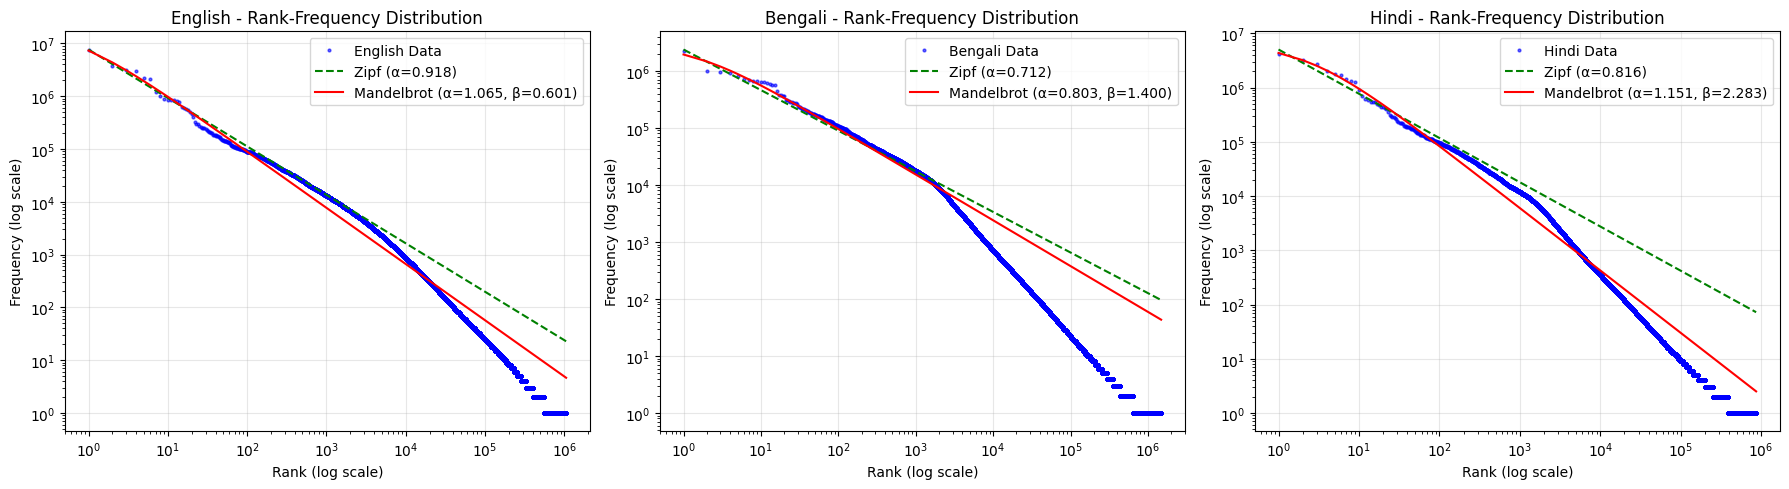



MODEL PARAMETERS AND FIT QUALITY - COMPARISON
+------------+------------------+-------------+------------+----------+---------+
|   Language |            Model |   Alpha (α) |   Beta (β) |       R² |    RMSE |
+============+==================+=============+============+==========+=========+
|    English |       Zipf's Law |    0.91753  |        N/A | 0.980384 | 1429.18 |
+------------+------------------+-------------+------------+----------+---------+
|    English | Mandelbrot's Law |    1.06501  |   0.601082 | 0.985484 | 1229.4  |
+------------+------------------+-------------+------------+----------+---------+
|    Bengali |       Zipf's Law |    0.712155 |        N/A | 0.947999 |  783.95 |
+------------+------------------+-------------+------------+----------+---------+
|    Bengali | Mandelbrot's Law |    0.803298 |   1.399639 | 0.965789 |  635.87 |
+------------+------------------+-------------+------------+----------+---------+
|      Hindi |       Zipf's Law |    0.815882 |   

In [ ]:


def zipf_mandelbrot_law_analysis(words, properties):
    '''
    Orchestrates Zipf-Mandelbrot law analysis pipeline.
    Fits models, calculates deviations, and returns comprehensive
    results for plotting and reporting.
    '''

    if not words:
        return

    frequencies, ranks = properties['frequencies'], properties['ranks']
    model_results = zipf_mandelbrot_models(ranks, frequencies)
    deviations = identify_deviation_points(ranks, frequencies, model_results)

    return [ranks,frequencies, model_results, deviations]



def zipf_printer(properties):

    ranks = [p[0] for p in properties]
    frequencies = [p[1] for p in properties]
    model_results = [p[2] for p in properties]
    deviations = [p[3] for p in properties]
    lang = [p[4] for p in properties]

    plot_law_analysis(ranks, frequencies, model_results,lang)

    print_zipf_prediction(model_results, lang)

    print_zipf_deviation(deviations, lang)

print("=" * 50)
print("ZIPF'S LAW ANALYSIS")
print("=" * 50)

zipf_results = []

for l,word_t, word_p in zip(languages,word_tokens,word_properties):
    zipf_results.append(zipf_mandelbrot_law_analysis(word_t,word_p)+[l]) # type: ignore

zipf_printer(zipf_results)

In [ ]:


def analyze_top_words(word_freq_dict, top_percent=5.0):
    '''
    Analyzes top percentage of most frequent words.
    Calculates individual and cumulative percentages of total corpus frequency
    occupied by top words.
    '''

    total_words = len(word_freq_dict)
    total_frequency = sum(word_freq_dict.values())

    num_top_words = math.ceil(total_words * top_percent / 100)
    top_words = sorted(word_freq_dict.items(), key=lambda x: x[1], reverse=True)[:num_top_words]

    df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])
    df['Rank'] = range(1, len(df) + 1)

    df['Percentage'] = (df['Frequency'] / total_frequency) * 100

    df['Cumulative_Percentage'] = df['Percentage'].cumsum()

    return df

def print_frequent_words(lang, top_words_df, m=7, max_display=70):
    '''
    Prints formatted table of most frequent words in grid layout.
    Displays words with their frequencies and shows cumulative
    percentage of corpus coverage.
    '''
    print('\n')
    print("=" * 50)
    print(f"MOST FREQUENT WORDS IN ",lang.upper())
    print("=" * 50)
    print(f"The top {len(top_words_df)} words account for {top_words_df['Cumulative_Percentage'].iloc[-1]:.1f}% of all word occurrences")

    words = top_words_df['Word'].tolist()[:max_display]
    n_rows = math.ceil(len(words) / m)

    grid = [words[i*m:(i+1)*m] for i in range(n_rows)]

    print(f"\nFrequent words:\n")
    print(tabulate(grid, tablefmt="grid"))


In [ ]:

def freuquent_word_analysis(properties, lang):
    '''Analyzes and prints most frequent words for a given language.'''

    word_freq_dict = properties['word_freq_dict']

    top_words_df = analyze_top_words(word_freq_dict, 5)
    print_frequent_words(lang,top_words_df)

for l,word_p in zip(languages,word_properties):
    freuquent_word_analysis(word_p,l)



MOST FREQUENT WORDS IN  ENGLISH
The top 52872 words account for 95.6% of all word occurrences

Frequent words:

+----------+--------+----------+------------+-------+------------+----------+
| the      | of     | in       | and        | a     | to         | was      |
+----------+--------+----------+------------+-------+------------+----------+
| s        | for    | as       | on         | is    | by         | with     |
+----------+--------+----------+------------+-------+------------+----------+
| from     | he     | at       | that       | his   | it         | an       |
+----------+--------+----------+------------+-------+------------+----------+
| were     | also   | which    | are        | new   | this       | be       |
+----------+--------+----------+------------+-------+------------+----------+
| first    | or     | had      | one        | after | its        | has      |
+----------+--------+----------+------------+-------+------------+----------+
| their    | align  | but   

# Zipf's Law Analysis

## English Corpus   
The English corpus strongly conforms to Zipfian behavior, with both Zipf’s law and Mandelbrot’s law fitting well. However, Mandelbrot’s law demonstrates a modestly superior fit (R² = 0.985 vs. 0.980) and reduces relative error significantly, particularly in the long tail of rare words. The top 5% of words are dominated by function words such as *the, of, and, to,* which are classic English stop words. This confirms that high-frequency items are largely grammatical glue rather than content-heavy tokens. Deviations emerge at very high ranks, where tokenization errors and specialized domain terms appear, producing inflated relative errors under Zipf’s law. Mandelbrot’s introduction of the β parameter better accounts for this flattening of the distribution. Overall, the analysis suggests that while Zipf’s law explains much of the English distribution, Mandelbrot’s law more accurately captures the nuanced behavior of infrequent words, yielding a stronger overall model fit.

---

## Bengali Corpus   
The Bengali corpus reveals a lower α value than English, reflecting greater inflectional richness in its morphology. Frequent words include *এবং, হয়, করে, একটি,* which function like stop words or auxiliary forms in Bengali. This indicates that verb inflections and postpositions dominate the top ranks, similar to how prepositions and auxiliary verbs appear in English but more morphologically diverse. While both models fit reasonably well, Mandelbrot’s law again outperforms Zipf’s law (R² = 0.965 vs. 0.948), reducing relative error by over 50%. The largest deviations occur in the long tail, where rare or mis-tokenized words, such as compound forms and orthographic variations, inflate counts. Bengali’s agglutinative tendencies increase vocabulary size, dispersing frequency mass across variants, which explains the relatively lower α. Overall, the data suggest that Mandelbrot’s law accommodates these complexities better, as it smooths the curve in the low-frequency region and provides a more faithful fit.

---

## Hindi Corpus   
The Hindi corpus shows a strong Zipfian trend, but with higher gains from Mandelbrot’s adjustment. Zipf’s α = 0.815 suggests a relatively flatter distribution than English, reflecting Hindi’s inflectional complexity, where case markers (*के, को, से*) and auxiliary verbs (*है, था, गया*) recur in high frequency. The top 5% of words are dominated by such function words, closely paralleling English stop words but shaped by postpositional structures and verb morphology. Mandelbrot’s model fits substantially better (R² = 0.990 vs. 0.951), reducing long-tail error by over 96%. This indicates that Hindi’s rich morphological system and tokenization inconsistencies (e.g., compound forms or script variants) are better captured by the β parameter. Deviations are most pronounced at high ranks, where spelling variations and rare domain-specific words appear. In sum, Hindi displays a stronger need for Mandelbrot’s correction than English or Bengali, highlighting how morphological richness shapes frequency distributions beyond the reach of classical Zipf.


# Calculating Vocabulary Growth

In [ ]:

def compute_vocabulary_growth(words, sample_points):
    '''
    Computes vocabulary growth curve by tracking unique words vs corpus size.
    Samples at regular intervals to build growth trajectory and
    returns corpus sizes, vocabulary sizes, and total statistics.
    '''

    total_tokens = len(words)
    step_size = max(1, total_tokens // sample_points)

    corpus_sizes = []
    vocabulary_sizes = []
    vocabulary = set()

    print(f"\nComputing vocabulary growth for {total_tokens:,} tokens...")

    for i in tqdm(range(len(words))):
        word = words[i]
        vocabulary.add(word)

        if i % step_size == 0 or i == total_tokens - 1:
            corpus_sizes.append(i + 1)
            vocabulary_sizes.append(len(vocabulary))

    return np.array(corpus_sizes), np.array(vocabulary_sizes),total_tokens,len(vocabulary)


In [ ]:
growth_data=[]
corpus_properties=[]

for l,word_t in zip(languages,word_tokens):
    cop,voc,tt,lenv = compute_vocabulary_growth(word_t, 0.01*len(word_t))
    growth_data.append([cop,voc])
    corpus_properties.append([tt,lenv])


Computing vocabulary growth for 113,146,814 tokens...


100%|██████████| 113146814/113146814 [00:34<00:00, 3248361.17it/s]



Computing vocabulary growth for 104,009,930 tokens...


100%|██████████| 104009930/104009930 [00:26<00:00, 3875749.76it/s]



Computing vocabulary growth for 88,757,626 tokens...


100%|██████████| 88757626/88757626 [00:28<00:00, 3166438.56it/s]


# Heap Analysis

In [ ]:


def heaps_law(N, K, beta):
    '''Implements Heaps' law formula: vocabulary = K * (N^beta).'''
    return K * (N ** beta)

def heaps_law_model(corpus_sizes, vocabulary_sizes):
    '''
    Fits Heaps' law to vocabulary growth data using curve fitting.
    Estimates K and beta parameters and calculates prediction
    quality metrics (R², MSE, RMSE).
    '''

    try:
        def heaps_wrapper(N, K, beta):
            return heaps_law(N, K, beta)

        initial_guess = [50.0, 0.5]

        params, _ = curve_fit(heaps_wrapper, corpus_sizes, vocabulary_sizes,
                            p0=initial_guess, maxfev=5000)

        K, beta = params

        predictions = heaps_law(corpus_sizes, K, beta)


        r2 = r2_score(vocabulary_sizes, predictions)
        mse = mean_squared_error(vocabulary_sizes, predictions)
        rmse = np.sqrt(mse)

        return {
            'K': K,
            'beta': beta,
            'r2': r2,
            'mse': mse,
            'rmse': rmse,
            'predictions': predictions
        }

    except Exception as e:
        print(f"Error fitting Heaps' law: {e}")
        return None


In [ ]:

def plot_heaps_law(corpus_sizes_list, vocabulary_sizes_list, heaps_results_list, languages):
    '''
    Plots vocabulary growth data with Heaps' law fits.
    Shows actual growth curves and fitted models for
    multiple languages with parameter annotations.
    '''

    n_languages = len(languages)

    n_cols = n_languages
    n_rows = (n_languages + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

    if n_languages > 1:
        axes = axes.flatten()
    else:
        axes = [axes]


    plot_colour = 'blue'
    heap_colour = 'red'

    for i, (corpus_sizes, vocabulary_sizes, heaps_results, language) in enumerate(zip(
        corpus_sizes_list, vocabulary_sizes_list, heaps_results_list, languages)):

        ax = axes[i]
        color = plot_colour
        marker ='o'

        ax.plot(corpus_sizes, vocabulary_sizes, marker, markersize=3, alpha=0.7,
                color=color, label=f'{language} Data')

        if heaps_results:
            ax.plot(corpus_sizes, heaps_results['predictions'], '-', linewidth=2,
                    color=heap_colour,
                    label=f"Heaps' Law (K={heaps_results['K']:.2f}, β={heaps_results['beta']:.3f})")

        ax.set_xlabel('Corpus Size')
        ax.set_ylabel('Vocabulary Size')
        ax.set_title(f'{language} - Vocabulary Growth\nR² = {heaps_results["r2"]:.4f}' if heaps_results else f'{language} - Vocabulary Growth')
        ax.legend()
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()



In [ ]:

def print_heap_results(heaps_results_list, languages):
    '''
    Prints formatted table of Heaps' law parameters.
    Displays K, beta, R², MSE, and RMSE values with
    qualitative assessment of fit quality for each language.
    '''

    print("=" * 60)
    print("HEAPS' LAW PARAMETERS - COMPARISON")
    print("=" * 60)

    table_data = []
    headers = ["Language", "K parameter", "β parameter", "R² score", "MSE", "RMSE"]

    for language, results in zip(languages, heaps_results_list):
        table_data.append([
            language,
            f"{results['K']:.4f}",
            f"{results['beta']:.4f}",
            f"{results['r2']:.4f}",
            f"{results['mse']:.4f}",
            f"{results['rmse']:.4f}"
        ])

    print(tabulate(table_data, headers=headers, tablefmt="grid", stralign="right"))

    print("\n" + "=" * 60)
    print("INDIVIDUAL LANGUAGE ANALYSIS:")
    print("=" * 60)

    for language, results in zip(languages, heaps_results_list):
        r2 = results['r2']
        if r2 >= 0.95:
            fit_quality = "Excellent fit"
        elif r2 >= 0.90:
            fit_quality = "Good fit"
        elif r2 >= 0.85:
            fit_quality = "Reasonable fit"
        else:
            fit_quality = "Poor fit"

        k = results['K']
        beta = results['beta']

        print(f"\n• {language}: {fit_quality} (R² = {r2:.4f})")
        print(f"  K = {k:.4f}, β = {beta:.4f}")



HEAPS' LAW ANALYSIS


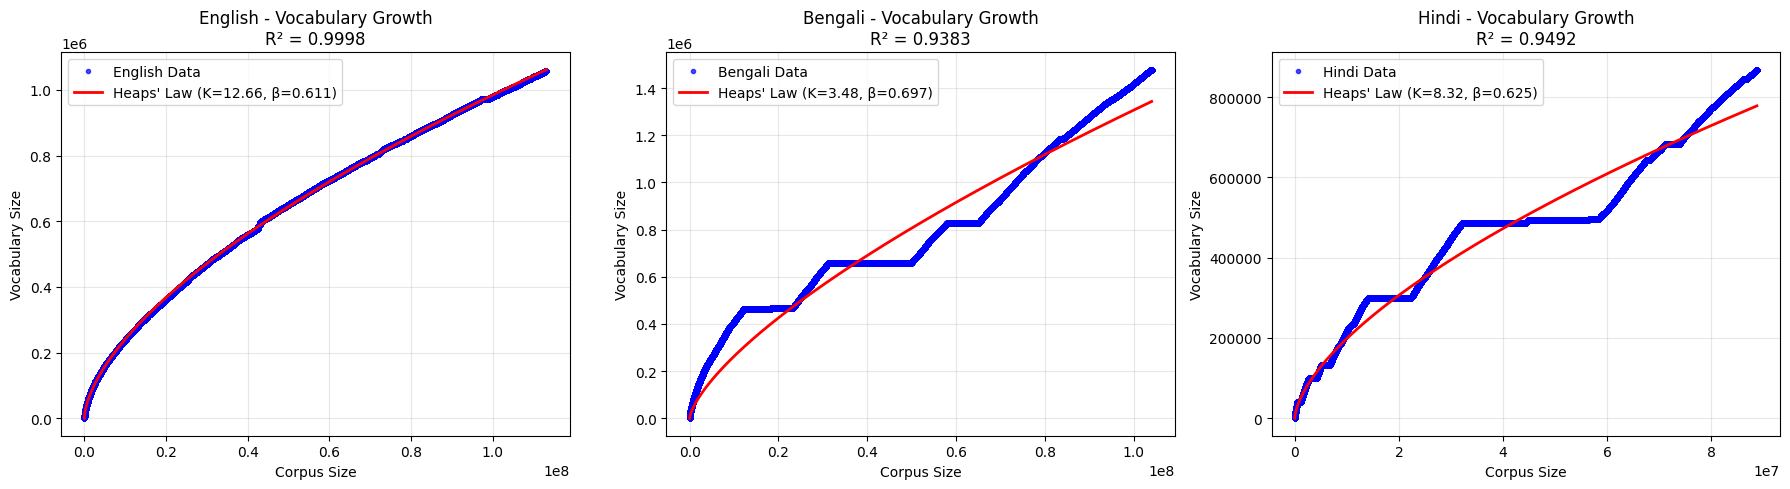

HEAPS' LAW PARAMETERS - COMPARISON
+------------+---------------+---------------+------------+-------------+----------+
|   Language |   K parameter |   β parameter |   R² score |         MSE |     RMSE |
+============+===============+===============+============+=============+==========+
|    English |       12.6594 |        0.6114 |     0.9998 | 1.62523e+07 |  4031.42 |
+------------+---------------+---------------+------------+-------------+----------+
|    Bengali |        3.4808 |        0.6968 |     0.9383 | 7.44698e+09 | 86295.9  |
+------------+---------------+---------------+------------+-------------+----------+
|      Hindi |        8.3246 |        0.6254 |     0.9492 | 2.07629e+09 | 45566.3  |
+------------+---------------+---------------+------------+-------------+----------+

INDIVIDUAL LANGUAGE ANALYSIS:

• English: Excellent fit (R² = 0.9998)
  K = 12.6594, β = 0.6114

• Bengali: Good fit (R² = 0.9383)
  K = 3.4808, β = 0.6968

• Hindi: Good fit (R² = 0.9492)
  K = 8.32

In [ ]:


def analyze_heaps_law(words, growth):
    '''Fits Heaps' law to vocabulary growth data and returns results.'''

    if not words:
        return None

    corpus_sizes, vocabulary_sizes = growth

    heaps_results = heaps_law_model(corpus_sizes, vocabulary_sizes)


    return heaps_results

def heap_printer(growth, heap_results, lang):

    corpus_sizes = [g[0] for g in growth]
    vocabulary_sizes = [g[1] for g in growth]

    plot_heaps_law(corpus_sizes, vocabulary_sizes, heap_results, lang)

    print_heap_results(heaps_results, lang)

print("\n" + "="*60)
print("HEAPS' LAW ANALYSIS")
print("="*60)

heaps_results=[]

for l,word_t,growth_d in zip(languages,word_tokens,growth_data):


    heaps_results.append(analyze_heaps_law(word_t, growth_d))

heap_printer(growth_data, heaps_results, languages)

# Heap's Law Analysis

## English Corpus   
The English corpus shows an almost perfect Heaps’ law fit (R² = 0.9998), indicating stable vocabulary growth modeling. With K = 12.66 and β = 0.61, the results suggest moderate vocabulary expansion. The β value reflects predictable growth, typical of English corpora with extensive reuse of function words and limited inflectional diversity.

---

## Bengali Corpus   
Bengali exhibits higher vocabulary growth (β = 0.697) compared to English and Hindi, reflecting its inflectional richness and morphological variations. Although the model fit is slightly weaker (R² = 0.938), it still captures the trend well. The relatively low K indicates slower initial growth but richer diversity as the corpus expands.

---

## Hindi Corpus   
Hindi shows good adherence to Heaps’ law (R² = 0.949) with K = 8.32 and β = 0.625. The moderate β suggests faster vocabulary expansion than English but slower than Bengali. This aligns with Hindi’s morphological complexity, where postpositions and verb inflections create diverse word forms, driving vocabulary growth across corpus size.


# Scaling Memory

In [ ]:

def memory_requirement(vocab_size,doc_count):
    '''Calculates memory requirements for vocabulary in bytes, MB, GB, and TB.'''

    bytes_needed = vocab_size * doc_count * 8
    by = bytes_needed
    mb = bytes_needed / (1024**2)
    gb = bytes_needed / (1024**3)
    tb = bytes_needed / (1024**4)
    return by,mb, gb, tb


def summarize_corpora(file_paths, growth, doc):
    '''
    Summarizes corpus statistics and memory requirements.
    Calculates vocabulary size, memory needs, and checks
    if vocabulary fits in available system RAM.
    '''

    table = []
    mem = []
    headers = ["Corpus", "Vocabulary", "Documents", "Memory (MB)", "Memory (GB)", "Memory (TB)", "Fits in Machine?"]

    available_ram = psutil.virtual_memory().available
    available_gb = available_ram / (1024**3)

    for file,gr,d in zip(file_paths,growth,doc):
        T = gr[0]
        V = gr[1]
        by, mb, gb, tb = memory_requirement(V,d)

        fits = "Yes" if (gb <= available_gb) else "No"

        mem.append({})
        mem[-1]["Corpus Size"]=T
        mem[-1]["Vocabulary Size"]=V
        mem[-1]["Memory Size"]=by
        mem[-1]["Fits"]=fits

        table.append([os.path.basename(file),f"{V:,}",f"{d:,}",f"{mb:,.2f}",f"{gb:,.2f}",f"{tb:,.3f}",fits])

    print(tabulate(table, headers=headers))
    print(f"\nAvailable system RAM: {available_gb:.2f} GB")

    return mem



memory_properties=summarize_corpora(corpus_files, corpus_properties, document_count)

Corpus                 Vocabulary    Documents      Memory (MB)      Memory (GB)    Memory (TB)  Fits in Machine?
---------------------  ------------  ------------ -------------  -------------  -------------  ------------------
english_processed.txt  1,057,440          345667    2,788,712.41        2,723.35           2.66   No
bengali_processed.txt  1,478,174          420554    4,742,828.28        4,631.66           4.52   No
hindi_processed.txt    868,332            239021    1,583,477.65        1,546.36           1.51   No


Available system RAM: 24 GB


## Memory Analysis

The incidence matrix requires terabyte-scale storage for all corpora, far exceeding the 24 GB system RAM. Thus, full in-memory representation is infeasible, demanding compression or sparse storage approaches.


# Regression on Heap's Law

In [ ]:

def heaps_law_regression(corpus_sizes, vocabulary_sizes):
    '''
    Fits Heaps' law using linear regression on log-transformed data.
    Applies log-log transformation and linear regression to
    estimate K and beta parameters with quality metrics.
    '''

    valid_indices = (corpus_sizes > 0) & (vocabulary_sizes > 0)
    corpus_sizes = corpus_sizes[valid_indices]
    vocabulary_sizes = vocabulary_sizes[valid_indices]

    log_N = np.log(corpus_sizes)
    log_V = np.log(vocabulary_sizes)

    finite_mask = np.isfinite(log_N) & np.isfinite(log_V)
    log_N = log_N[finite_mask]
    log_V = log_V[finite_mask]


    model = LinearRegression()
    model.fit(log_N.reshape(-1, 1), log_V)

    beta = model.coef_[0]
    log_K = model.intercept_
    K = np.exp(log_K)

    log_pred = model.predict(log_N.reshape(-1, 1))
    predictions = np.exp(log_pred)

    r2 = r2_score(log_V, log_pred)
    mse = mean_squared_error(vocabulary_sizes, predictions)
    rmse = np.sqrt(mse)

    return {
        'K': K,
        'beta': beta,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'predictions': predictions
    }

In [ ]:

def plot_heaps_law_regression(corpus_sizes_list, vocabulary_sizes_list, results_list, languages):
    '''
    Plots log-log vocabulary growth with regression fits.
    Shows actual data and Heaps' law predictions on logarithmic scales
    for multiple language comparison.
    '''

    n_languages = len(languages)

    n_cols = n_languages
    n_rows = (n_languages + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

    if n_languages > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    plot_color = 'blue'
    regression_colour = 'red'

    for i, (corpus_sizes, vocabulary_sizes, results, language) in enumerate(zip(
        corpus_sizes_list, vocabulary_sizes_list, results_list, languages)):

        ax = axes[i]
        marker = 'o'

        ax.plot(corpus_sizes, vocabulary_sizes, marker, markersize=3, alpha=0.7,
                color=plot_color, label=f'{language} Data')

        ax.plot(corpus_sizes, results['predictions'], '-', linewidth=2,
                color=regression_colour,
                label=f'Heaps\' Law Fit (K={results["K"]:.2f}, β={results["beta"]:.3f})')

        ax.set_xlabel('Corpus Size (log scale)')
        ax.set_ylabel('Vocabulary Size (log scale)')
        ax.set_title(f'{language} - Heaps\' Law (Regression)\nR² = {results["r2"]:.4f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xscale('log')
        ax.set_yscale('log')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


def print_regression_results(results_list, languages):
    '''
    Prints regression-based Heaps' law parameters.
    Displays K, beta, R², MSE, and RMSE values with
    fit quality assessment for each language.
    '''

    print('\n')
    print("=" * 80)
    print(f"HEAPS' LAW FITTING RESULTS (Linear Regression on Log-Transformed Data)")
    print("=" * 80)

    table_data = []
    headers = ["Language", "K parameter", "β parameter", "R² score", "MSE", "RMSE"]

    for language, results in zip(languages, results_list):
        table_data.append([
            language,
            f"{results['K']:.4f}",
            f"{results['beta']:.4f}",
            f"{results['r2']:.4f}",
            f"{results['mse']:.4f}",
            f"{results['rmse']:.4f}"
        ])

    print(tabulate(table_data, headers=headers, tablefmt="grid", stralign="right"))

    print("\n" + "=" * 80)
    print("FIT QUALITY ASSESSMENT:")
    print("=" * 80)

    for language, results in zip(languages, results_list):
        r2 = results['r2']
        if r2 >= 0.95:
            assessment = "Excellent fit"
        elif r2 >= 0.90:
            assessment = "Good fit"
        elif r2 >= 0.85:
            assessment = "Reasonable fit"
        else:
            assessment = "Poor fit"

        print(f"• {language}: {assessment} (R² = {r2:.4f})")


In [ ]:

def analyze_regression(words, growth):
    '''Performs Heaps' law analysis using regression on log-transformed data.'''

    if not words:
        return None


    corpus_sizes, vocabulary_sizes = growth

    results = heaps_law_regression(corpus_sizes, vocabulary_sizes)

    return results

def regression_printer(growth,results,lang):

    corpus_sizes = [g[0] for g in growth]
    vocabulary_sizes = [g[1] for g in growth]
    plot_heaps_law_regression(corpus_sizes, vocabulary_sizes, results, lang)
    print_regression_results(results,lang)


HEAP'S LAW via REGRESSION 


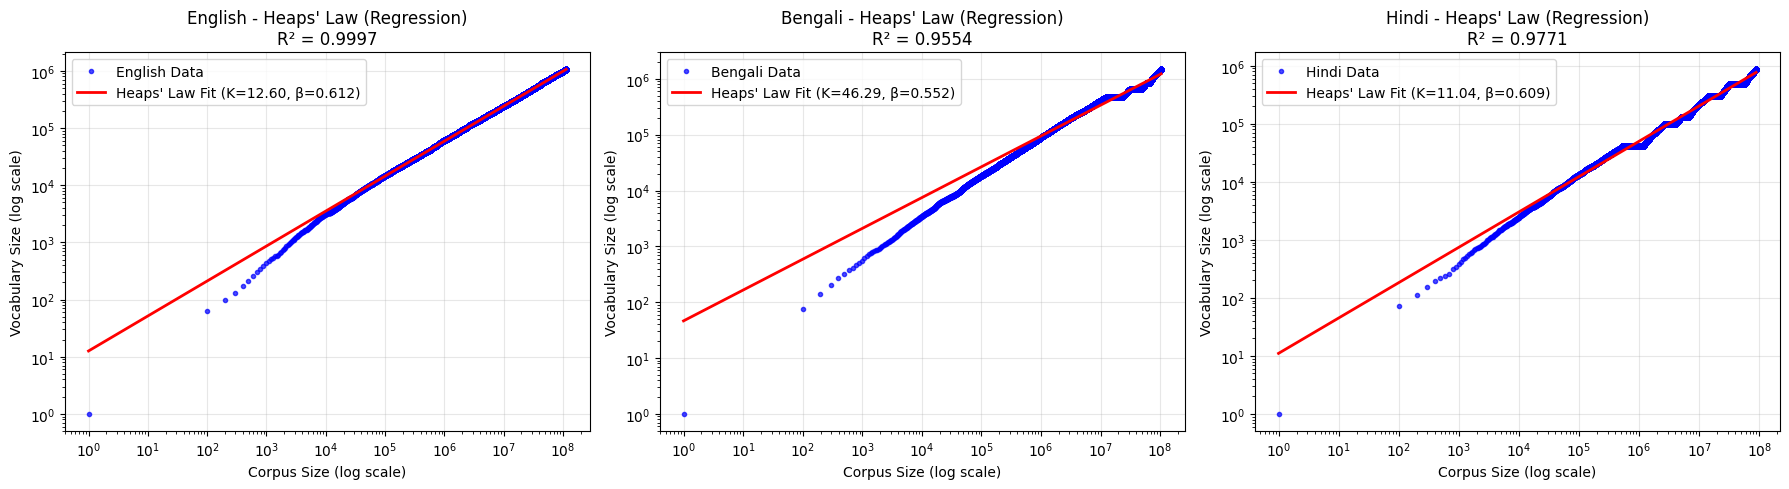



HEAPS' LAW FITTING RESULTS (Linear Regression on Log-Transformed Data)
+------------+---------------+---------------+------------+-------------+-----------+
|   Language |   K parameter |   β parameter |   R² score |         MSE |      RMSE |
+============+===============+===============+============+=============+===========+
|    English |       12.6029 |        0.6116 |     0.9997 | 1.63414e+07 |   4042.45 |
+------------+---------------+---------------+------------+-------------+-----------+
|    Bengali |       46.2889 |        0.5518 |     0.9554 | 1.04786e+10 | 102365    |
+------------+---------------+---------------+------------+-------------+-----------+
|      Hindi |       11.042  |        0.6093 |     0.9771 | 2.09315e+09 |  45751    |
+------------+---------------+---------------+------------+-------------+-----------+

FIT QUALITY ASSESSMENT:
• English: Excellent fit (R² = 0.9997)
• Bengali: Excellent fit (R² = 0.9554)
• Hindi: Excellent fit (R² = 0.9771)


In [ ]:

print("=" * 40)
print("HEAP'S LAW via REGRESSION ",)
print("=" * 40)

regression_results=[]

for l,word_t,growth_d in zip(languages,word_tokens,growth_data):

    regression_results.append(analyze_regression(word_t, growth_d))

regression_printer(growth_data,regression_results,languages)


In [ ]:
def compare_fitting_methods(regression_results, curve_fit_results):
    '''
    Compares regression vs curve fitting methods for Heaps' law.
    Calculates parameter differences and determines which method
    provides better fit based on R² values.
    '''

    comparison_data = [
        {
            'Method': 'Linear Regression (Log-Transformed)',
            'K': regression_results['K'],
            'β': regression_results['beta'],
            'R²': regression_results['r2'],
            'MSE': regression_results['mse'],
            'RMSE': regression_results['rmse']
        },
        {
            'Method': 'Direct Curve Fitting',
            'K': curve_fit_results['K'],
            'β': curve_fit_results['beta'],
            'R²': curve_fit_results['r2'],
            'MSE': curve_fit_results['mse'],
            'RMSE': curve_fit_results['rmse']
        }
    ]

    df = pd.DataFrame(comparison_data)

    k_diff = abs(df.loc[0, 'K'] - df.loc[1, 'K']) / df.loc[0, 'K'] * 100 # type: ignore
    beta_diff = abs(df.loc[0, 'β'] - df.loc[1, 'β']) / df.loc[0, 'β'] * 100 # type: ignore
    r2_diff = df.loc[0, 'R²'] - df.loc[1, 'R²'] # type: ignore

    print("=" * 100)
    print(df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))
    print("\n" + "=" * 100)
    print("PARAMETER DIFFERENCES:")
    print(f"K parameter difference: {k_diff:.2f}%")
    print(f"β parameter difference: {beta_diff:.2f}%")
    print(f"R² difference: {abs(r2_diff):.6f}") # type: ignore

    if regression_results['r2'] > curve_fit_results['r2']:
        better_method = "Linear Regression (Log-Transformed)"
        improvement = regression_results['r2'] - curve_fit_results['r2']
        print(f"\nBetter fit: {better_method} (R² improvement: {improvement:.6f})")
    elif curve_fit_results['r2'] > regression_results['r2']:
        better_method = "Direct Curve Fitting"
        improvement = curve_fit_results['r2'] - regression_results['r2']
        print(f"\nBetter fit: {better_method} (R² improvement: {improvement:.6f})")
    else:
        print(f"\nBoth methods provide identical fit quality")




for l,reg,heap in zip(languages,regression_results,heaps_results):
    print("\n"+"=" * 50)
    print("COMPARING MODELS for ",l)
    compare_fitting_methods(reg, heap)


COMPARING MODELS for  English
                             Method         K        β       R²             MSE        RMSE
Linear Regression (Log-Transformed) 12.602865 0.611593 0.999739 16341426.842344 4042.453072
               Direct Curve Fitting 12.659411 0.611368 0.999778 16252321.474679 4031.416807

PARAMETER DIFFERENCES:
K parameter difference: 0.45%
β parameter difference: 0.04%
R² difference: 0.000039

Better fit: Direct Curve Fitting (R² improvement: 0.000039)

COMPARING MODELS for  Bengali
                             Method         K        β       R²                MSE          RMSE
Linear Regression (Log-Transformed) 46.288881 0.551802 0.955426 10478641736.731604 102365.236954
               Direct Curve Fitting  3.480764 0.696814 0.938326  7446984685.070401  86295.913490

PARAMETER DIFFERENCES:
K parameter difference: 92.48%
β parameter difference: 26.28%
R² difference: 0.017101

Better fit: Linear Regression (Log-Transformed) (R² improvement: 0.017101)

COMPARING MODEL

# Regression on Heap's Law Analysis

## English Corpus   
The regression-based fitting for English aligns very closely with the direct curve fitting results (K ≈ 12.60, β ≈ 0.61). The R² = 0.9997 confirms an almost perfect linear relationship on log-transformed data. This stability highlights English’s predictable vocabulary growth, driven largely by limited inflectional variation and frequent reuse of function words.

---

## Bengali Corpus   
For Bengali, regression fitting yields notably different parameters (K = 46.29, β = 0.55) compared to curve fitting, though the overall fit remains strong (R² = 0.955). The higher K and lower β suggest faster early vocabulary growth but slower long-term expansion. This reflects Bengali’s morphological richness, where affixes and variants increase vocabulary diversity.

---

## Hindi Corpus   
In Hindi, regression estimates (K = 11.04, β = 0.61) remain close to direct fitting values, with R² = 0.977. The results reaffirm good adherence to Heaps’ law. The β value indicates moderate vocabulary growth, shaped by inflectional morphology and postpositional structures, while the slightly higher K reflects steady early expansion across tokens.


# Corpus Comparison

In [ ]:

def compare_all_languages(zipf, heap_list, regression_list, mem_list, languages):
    '''
    Creates comprehensive comparison table across all analyses.
    Compares Zipf, Heaps, regression parameters and memory requirements
    for all languages with key insights and best performers.
    '''

    zipf_list = [z[2] for z in zipf]

    comparison_data = []

    comparison_data.append(["Zipf's Law - α (Zipf)"] + [f"{zipf['zipf']['alpha']:.4f}" for zipf in zipf_list])
    comparison_data.append(["Zipf's Law - α (Mandelbrot)"] + [f"{zipf['mandelbrot']['alpha']:.4f}" for zipf in zipf_list])
    comparison_data.append(["Zipf's Law - β (Mandelbrot)"] + [f"{zipf['mandelbrot']['beta']:.4f}" for zipf in zipf_list])
    comparison_data.append(["Zipf's Law - R² (Zipf)"] + [f"{zipf['zipf']['r2']:.4f}" for zipf in zipf_list])
    comparison_data.append(["Zipf's Law - R² (Mandelbrot)"] + [f"{zipf['mandelbrot']['r2']:.4f}" for zipf in zipf_list])
    comparison_data.append(["Zipf's Law - Best Fit"] + [
        "Mandelbrot" if zipf['mandelbrot']['r2'] > zipf['zipf']['r2'] else "Zipf"
        for zipf in zipf_list
    ])

    comparison_data.append(["-" * 30] + ["-" * 15] * len(languages))

    comparison_data.append(["Heaps' Law - K"] + [f"{heap['K']:.4f}" for heap in heap_list])
    comparison_data.append(["Heaps' Law - β"] + [f"{heap['beta']:.4f}" for heap in heap_list])
    comparison_data.append(["Heaps' Law - R²"] + [f"{heap['r2']:.4f}" for heap in heap_list])
    comparison_data.append(["Heaps' Law - Fit Quality"] + [
        "Excellent" if heap['r2'] >= 0.95 else "Good" if heap['r2'] >= 0.90 else "Reasonable"
        for heap in heap_list
    ])

    comparison_data.append(["-" * 30] + ["-" * 15] * len(languages))

    comparison_data.append(["Regression - K"] + [f"{reg['K']:.4f}" for reg in regression_list])
    comparison_data.append(["Regression - β"] + [f"{reg['beta']:.4f}" for reg in regression_list])
    comparison_data.append(["Regression - R²"] + [f"{reg['r2']:.4f}" for reg in regression_list])

    comparison_data.append(["-" * 30] + ["-" * 15] * len(languages))

    comparison_data.append(["Corpus Size (tokens)"] + [f"{mem['Corpus Size']:,}" for mem in mem_list])
    comparison_data.append(["Vocabulary Size"] + [f"{mem['Vocabulary Size']:,}" for mem in mem_list])
    comparison_data.append(["Memory Required"] + [str(int((mem['Memory Size']/1e12)*100)/100)+" TB"for mem in mem_list])
    comparison_data.append(["Fits in Memory"] + [mem['Fits'] for mem in mem_list])

    headers = ["Property"] + languages

    print("=" * 80)
    print("COMPREHENSIVE LANGUAGE COMPARISON")
    print("=" * 80)
    print(tabulate(comparison_data, headers=headers, tablefmt="grid", stralign="right"))

    print("\n" + "=" * 80)
    print("KEY INSIGHTS:")
    print("=" * 80)

    best_zipf_idx = np.argmax([zipf['mandelbrot']['r2'] for zipf in zipf_list])
    print(f"• Best Zipf's Law fit: {languages[best_zipf_idx]} (R² = {zipf_list[best_zipf_idx]['mandelbrot']['r2']:.4f})")

    best_heap_idx = np.argmax([heap['r2'] for heap in heap_list])
    print(f"• Best Heaps' Law fit: {languages[best_heap_idx]} (R² = {heap_list[best_heap_idx]['r2']:.4f})")

    best_reg_idx = np.argmax([reg['r2'] for reg in regression_list])
    print(f"• Best Regression fit: {languages[best_reg_idx]} (R² = {regression_list[best_reg_idx]['r2']:.4f})")

    largest_vocab_idx = np.argmax([mem['Vocabulary Size'] for mem in mem_list])
    print(f"• Largest vocabulary: {languages[largest_vocab_idx]} ({mem_list[largest_vocab_idx]['Vocabulary Size']:,} words)")


compare_all_languages(zipf_results, heaps_results, regression_results, memory_properties, languages)

COMPREHENSIVE LANGUAGE COMPARISON
+--------------------------------+-----------------+-----------------+-----------------+
|                       Property |         English |         Bengali |           Hindi |
+================================+=================+=================+=================+
|          Zipf's Law - α (Zipf) |          0.9175 |          0.7122 |          0.8159 |
+--------------------------------+-----------------+-----------------+-----------------+
|    Zipf's Law - α (Mandelbrot) |          1.0650 |          0.8033 |          1.1511 |
+--------------------------------+-----------------+-----------------+-----------------+
|    Zipf's Law - β (Mandelbrot) |          0.6011 |          1.3996 |          2.2834 |
+--------------------------------+-----------------+-----------------+-----------------+
|         Zipf's Law - R² (Zipf) |          0.9804 |          0.9480 |          0.9506 |
+--------------------------------+-----------------+-----------------+------

# Corpus Analysis

## English Corpus Analysis  
For English, both Zipf’s and Heaps’ laws provided excellent fits, demonstrating predictable statistical behavior typical of large English corpora. In Zipf’s law modeling, the α parameter was 0.918 under the standard model, while Mandelbrot’s variant raised α to 1.065 and introduced β = 0.601. The Mandelbrot model clearly offered a superior fit (R² = 0.986 vs. 0.980 for Zipf) and significantly reduced error in the long tail of the rank-frequency distribution. This indicates that while Zipf’s original formulation captures general frequency decay, Mandelbrot’s adjustment better accommodates the flattened tail distribution of rare English words. The improvement is expected in English since low-frequency words include many technical terms, proper nouns, and borrowed forms.  

Heaps’ law fitting yielded K = 12.66 and β = 0.611, with an exceptionally strong R² = 0.9998, confirming that vocabulary growth in English is both predictable and relatively modest. Regression fitting on log-transformed data yielded nearly identical results (K = 12.60, β = 0.612, R² = 0.9997), further reinforcing stability. The moderate β reflects limited morphological complexity and heavy reliance on function words such as *the, of, and, to*, which dominate the distribution and suppress rapid vocabulary expansion. The near-equivalence of direct and regression-based fitting suggests that English corpora are relatively stable and insensitive to modeling choice, due to the language’s analytic structure.  

For English, regression fitting of Heaps’ law yielded highly stable parameters (K = 12.60, β = 0.612) with an excellent R² = 0.9997. This confirms predictable vocabulary growth, reflecting limited morphological complexity and heavy reliance on frequent function words. Minimal deviation indicates that preprocessing like stop word removal is sufficient for robust NLP modeling.  

Minimal deviation between fits indicates that preprocessing requirements for English are straightforward: stopword removal and normalization suffice for robust NLP modeling. Rare words contribute little noise, and the predictable statistical structure ensures that word embeddings and frequency-based methods remain reliable without advanced morphological analysis.  

The English corpus contained ~113 million tokens, with a vocabulary size of ~1.06 million words. Memory requirements for a full co-occurrence matrix are ~2.66 TB, highlighting the need for dimensionality reduction or sparse representation for practical NLP applications.  

---

## Bengali Corpus Analysis  
The Bengali corpus reflects more complex morphological and inflectional behavior compared to English. In Zipf’s law fitting, the standard model estimated α = 0.712, but Mandelbrot’s law adjusted this to α = 0.803 with β = 1.400, producing a higher-quality fit (R² = 0.966 vs. 0.948). This demonstrates that Mandelbrot’s correction significantly reduces error, especially for infrequent words, which are more numerous in Bengali due to extensive inflections, compound formations, and orthographic variants. Relative error reduction exceeded 50%, underscoring the necessity of Mandelbrot’s law for morphologically rich and agglutinative languages.  

Heaps’ law produced K = 3.48 and β = 0.697, with an R² = 0.938, reflecting strong but noisier vocabulary growth compared to English. The relatively high β indicates that vocabulary expands faster as corpus size increases, consistent with Bengali’s inflectional richness and compounding processes. Regression-based fitting produced very different estimates (K = 46.29, β = 0.552), though with improved R² = 0.955. This discrepancy highlights parameter instability under different modeling approaches, which likely arises from the inflated vocabulary space caused by morphological variants and inconsistent orthographic usage.  

Bengali showed higher variability in parameter estimation, with regression yielding K = 46.29 and β = 0.552 (R² = 0.955). The deviations reflect morphological richness, compounding, and inflectional variants that inflate vocabulary growth. This suggests Bengali requires advanced preprocessing such as lemmatization and morphological analysis to prevent vocabulary explosion and improve NLP model efficiency.

The deviation between direct curve fitting and regression suggests that Bengali requires more sophisticated preprocessing. Lemmatization, stemming, and normalization are critical to reduce vocabulary explosion and stabilize model parameters. Without such steps, downstream NLP tasks such as embedding training or language modeling risk high sparsity and inefficient learning.  

The Bengali corpus contained ~104 million tokens, with the largest vocabulary size (~1.48 million words) among the three languages. Memory requirements exceeded ~4.52 TB, the highest computational footprint observed. This reflects the computational burden of morphologically complex languages and emphasizes the need for aggressive vocabulary pruning and morphological analysis in Bengali NLP pipelines.  

---

## Hindi Corpus Analysis  
The Hindi corpus displays intermediate characteristics between English and Bengali. Under Zipf’s law, α was 0.816 for the standard model, increasing to 1.151 with Mandelbrot’s adjustment, with β = 2.283. The improvement was dramatic, with R² rising from 0.951 to 0.990 — the strongest Zipf-family fit among the three languages. The large β reflects strong long-tail flattening, consistent with Hindi’s linguistic structure: extensive inflection, postpositions, compounding, and loanword diversity generate many rare forms, which Mandelbrot models more effectively than Zipf.  

Heaps’ law fitting yielded K = 8.32 and β = 0.625, with R² = 0.949, suggesting relatively rapid vocabulary growth compared to English. The slightly higher β reflects the productive role of morphological and syntactic variation in expanding Hindi’s vocabulary space. Regression-based fitting produced somewhat higher K (11.04) and a similar β (0.609), improving R² to 0.977. This consistency across methods suggests that Hindi exhibits stable statistical properties despite its morphological richness, though with more variability than English.  

Hindi regression fitting gave K = 11.04 and β = 0.609, with R² = 0.977, reflecting strong predictability but with more variability than English. Its agglutinative nature and postpositional constructions increase lexical diversity. For NLP, stemming and normalization are essential, as raw corpora risk sparse embeddings and unstable model training.

From an NLP perspective, Hindi requires more extensive preprocessing than English but less than Bengali. Stemming, lemmatization, and normalization are necessary to prevent sparse embeddings and unstable model training. Stopword removal alone is insufficient, since morphological variants inflate the vocabulary disproportionately. The results indicate that while Heaps’ law predicts robust growth, unchecked vocabulary expansion will strain NLP systems without morphological handling.  

The Hindi corpus contained ~88.8 million tokens, with a vocabulary size of ~868,000 words. Memory requirements were ~1.51 TB, making it computationally heavy but the smallest among the three corpora. The smaller footprint suggests Hindi NLP is more tractable than Bengali, though preprocessing remains essential to achieve stable modeling performance.  



# Comparative Discussion  
Across the three corpora, notable linguistic and computational differences emerge. English exhibits the most stable and predictable behavior, with Zipf’s α near 1, moderate Heaps’ β (~0.61), and nearly perfect fits under both direct and regression models. Bengali shows the steepest vocabulary growth (Heaps’ β ≈ 0.70), consistent with its morphological richness, but also the highest computational cost due to the largest vocabulary size. Hindi falls between the two, with moderate vocabulary growth (β ≈ 0.62) but a very strong improvement under Mandelbrot’s law, reflecting its inflectional and postpositional structure.  

From a computational standpoint, none of the Vocabulary-Document Incidence matrix fit into standard memory: English requires ~2.66 TB, Bengali ~4.52 TB, and Hindi ~1.51 TB. All three demand optimization strategies such as sparse storage or subword tokenization.  

